In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns


Splitting data into stratified groups where identical patient ids belong to same groups.

Runs Pearson correlation first on correlation between the different features to test if any features are redundant.
After this we prioritise features based on their correlation with diagnosis.

In [3]:
path="../../results/reports/features.csv"

df = pd.read_csv(path)


X = df[['melanoma_color_count','hue_variance',
 'saturation_variance','value_variance','mabrouk_asymmetry_score',
 'avg_asymmetry_score','worst_score','Polsby-Popper','convexity_score',
 'lesion_red_share','lesion_green_share','lesion_blue_share',
 'lesion_skin_red_diff','lesion_skin_green_diff','lesion_skin_blue_diff',
 'lesion_skin_rgb_distance']]
y = df["skin_cancer_diagnosis"]


# Smaller df grouped by patiend_id
patient_labels = df.groupby("patient_id")["skin_cancer_diagnosis"].max()

patients = patient_labels.index
labels = patient_labels.values

# Splits by patiend id and stratify by patients using .max() to check if patient have a cancerous lesion. 
# First split: train vs test+val
train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


train_mask = df["patient_id"].isin(train_patients)
test_mask = df["patient_id"].isin(test_patients)


X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

# Check distribution of rows in each split
total_rows = len(df)

threshold = 0.8
max_allowed = 3
corr = X_train.corr().abs().fillna(0)
counts = (corr > threshold).sum(axis=1) - 1
to_drop = counts[counts > max_allowed].index.tolist()
X_reduced = X_train.drop(columns=to_drop)

# rank by absolute correlation with label and pick top 10
label_col = "Skin_cancer_diagnosis"
df_rank = X_reduced.copy()
df_rank[label_col] = y_train
corr_with_label = df_rank.corr().abs()[label_col].drop(label_col).fillna(0)
top10 = corr_with_label.sort_values(ascending=False).head(10).index.tolist()

X_train = X_train[top10]
X_test = X_test[top10]

y = df['skin_cancer_diagnosis']

In [4]:
print("X split distribution:")
print("Train:", round(len(X_train) / total_rows, 3))
print("Test:", round(len(X_test) / total_rows, 3))

# Check cancer vs non-cancer distribution in each split
print("\nTrain cancer distribution:")
print(y_train.value_counts().sort_index())
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest cancer distribution:")
print(y_test.value_counts().sort_index())
print(y_test.value_counts(normalize=True).sort_index())

X split distribution:
Train: 0.792
Test: 0.208

Train cancer distribution:
skin_cancer_diagnosis
0    833
1    825
Name: count, dtype: int64
skin_cancer_diagnosis
0    0.502413
1    0.497587
Name: proportion, dtype: float64

Test cancer distribution:
skin_cancer_diagnosis
0    218
1    218
Name: count, dtype: int64
skin_cancer_diagnosis
0    0.5
1    0.5
Name: proportion, dtype: float64


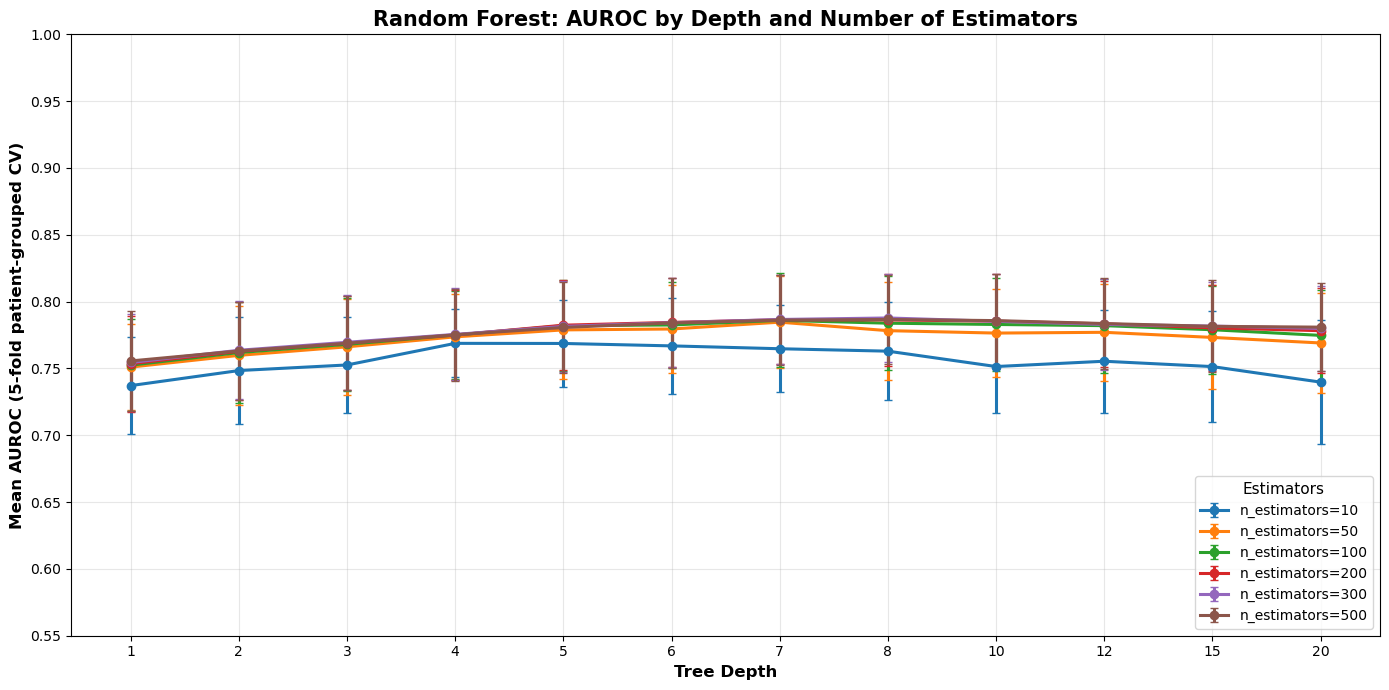

In [5]:
groups_train = df.loc[X_train.index, "patient_id"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
estimators = [10, 50, 100, 200, 300, 500]

mean_auc = {n: [] for n in estimators}
std_auc = {n: [] for n in estimators}

for n in estimators:
    for depth in depths:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )

        scores = cross_val_score(
            rf,
            X_train,
            y_train,
            cv=cv,
            groups=groups_train,
            scoring='roc_auc',
            n_jobs=-1
        )

        mean_auc[n].append(scores.mean())
        std_auc[n].append(scores.std())

x_positions = list(range(len(depths)))
labels = [str(d) for d in depths]

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, n in enumerate(estimators):
    ax.errorbar(
        x_positions,
        mean_auc[n],
        yerr=std_auc[n],
        fmt='-o',
        capsize=3,
        linewidth=2.2,
        markersize=6,
        color=colors[i],
        label=f'n_estimators={n}'
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(labels)
ax.set_xlabel('Tree Depth', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean AUROC (5-fold patient-grouped CV)', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: AUROC by Depth and Number of Estimators', fontsize=15, fontweight='bold')
ax.legend(title='Estimators', fontsize=10, title_fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.55, 1])

plt.tight_layout()
plt.show()

In [6]:
groups_train = df.loc[X_train.index, "patient_id"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
estimators = [10, 50, 100, 200, 300, 500]

results = []

for n in estimators:
    for depth in depths:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            class_weight={0: 1, 1: 2}
        )

        scores = cross_val_score(
            rf,
            X_train,
            y_train,
            cv=cv,
            groups=groups_train,
            scoring='roc_auc',
            n_jobs=-1
        )

        mean_score = scores.mean()


        results.append((
            n,
            depth,
            mean_score,
        ))


top1 = sorted(results, key=lambda x: x[2])[-1]

n_estimators = top1[0]
depth= top1[1]
auc= top1[2]

In [7]:
print(f"estimators: {n_estimators} depth: {depth} auc: {auc}")

estimators: 500 depth: 15 auc: 0.7848510944098251


For finetuning and trying different depths, estimators and weight based on observations.

In [8]:
# Patient groups for the training data
groups_train = df.loc[X_train.index, "patient_id"]

# Cross-validation that keeps each patient in only one fold
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model to evaluate
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

# Cross-validation scores
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    groups=groups_train,
    scoring="roc_auc"
)

print("ROC AUC scores:", scores)
print(f"Mean ROC AUC: {scores.mean():.4f}")
print(f"Std ROC AUC: {scores.std():.4f}")

ROC AUC scores: [0.80611033 0.73718397 0.77517645 0.83720356 0.78313783]
Mean ROC AUC: 0.7878
Std ROC AUC: 0.0332


In [9]:
groups_train = df.loc[X_train.index, "patient_id"]

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_true_all = []
y_proba_all = []

for train_idx, test_idx in cv.split(X_train, y_train, groups_train):

    X_tr = X_train.iloc[train_idx]
    X_te = X_train.iloc[test_idx]

    y_tr = y_train.iloc[train_idx]
    y_te = y_train.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=7,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_tr, y_tr)

    y_pred_proba = model.predict_proba(X_te)[:, 1]

    y_true_all.extend(y_te)
    y_proba_all.extend(y_pred_proba)

y_true_all = np.array(y_true_all)
y_proba_all = np.array(y_proba_all)

fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', linewidth=3,
         label=f'ROC curve (AUC = {roc_auc_value:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2,
         label='Random guessing (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve (StratifiedGroupKFold)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f'ROC AUC = {roc_auc_value:.4f}')

TypeError: 'numpy.float64' object is not callable

Exception ignored in: <function ResourceTracker.__del__ at 0x1043298a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1042c98a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1119a58a0>
Traceback (most recent call last

Depth can be changed between 7 and 8 depending on what CM is more desiarable.

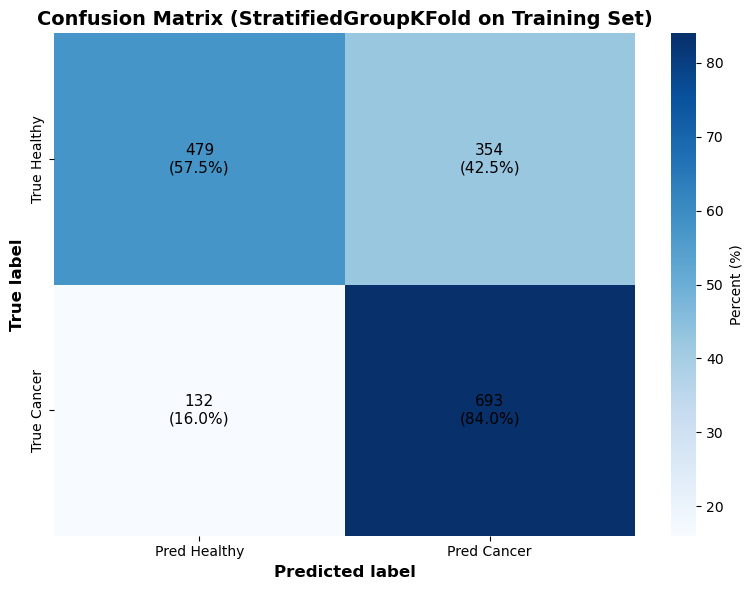

In [ ]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_true_all = []
y_pred_all = []

for train_idx, val_idx in cv.split(X_train, y_train, groups_train):

    X_tr = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=7,
        random_state=42,
        class_weight={0: 1, 1: 2.2}
    )

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val_fold)

    y_true_all.extend(y_val_fold)
    y_pred_all.extend(y_pred)

# convert to arrays
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

labels = ['Healthy', 'Cancer']

# plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_pct,
    annot=False,
    cmap='Blues',
    cbar=True,
    xticklabels=[f'Pred {l}' for l in labels],
    yticklabels=[f'True {l}' for l in labels],
    cbar_kws={'label': 'Percent (%)'}
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j + 0.5,
            i + 0.5,
            f'{cm[i, j]}\n({cm_pct[i, j]:.1f}%)',
            ha='center',
            va='center',
            color='black',
            fontsize=11
        )

plt.xlabel('Predicted label', fontsize=12, fontweight='bold')
plt.ylabel('True label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix (StratifiedGroupKFold on Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Patient groups for the training data
groups_train = df.loc[X_train.index, "patient_id"]

# Cross-validation setup
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Loop over class_weight values
for i in np.arange(1.0, 3.1, 0.1):

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        random_state=42,
        class_weight={0: 1, 1: round(i, 1)}
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="roc_auc"
    )

    print(
        f"class_weight_1 = {i:.1f} "
        f"- Mean AUC: {scores.mean():.4f} "
        f"- Std: {scores.std():.4f} "
        f"- Fold scores: {np.round(scores, 4)}"
    )


class_weight_1 = 1.0 - Mean AUC: 0.7862 - Std: 0.0341 - Fold scores: [0.8008 0.7342 0.776  0.8389 0.7811]
class_weight_1 = 1.1 - Mean AUC: 0.7852 - Std: 0.0353 - Fold scores: [0.8026 0.7323 0.7707 0.8392 0.7815]
class_weight_1 = 1.2 - Mean AUC: 0.7865 - Std: 0.0370 - Fold scores: [0.8065 0.7301 0.772  0.8414 0.7826]
class_weight_1 = 1.3 - Mean AUC: 0.7859 - Std: 0.0370 - Fold scores: [0.8049 0.7286 0.7713 0.8407 0.7839]
class_weight_1 = 1.4 - Mean AUC: 0.7860 - Std: 0.0374 - Fold scores: [0.8044 0.7272 0.7744 0.8414 0.7828]
class_weight_1 = 1.5 - Mean AUC: 0.7860 - Std: 0.0385 - Fold scores: [0.8054 0.725  0.7735 0.8422 0.7839]
class_weight_1 = 1.6 - Mean AUC: 0.7851 - Std: 0.0391 - Fold scores: [0.8057 0.7239 0.7697 0.842  0.7842]
class_weight_1 = 1.7 - Mean AUC: 0.7848 - Std: 0.0412 - Fold scores: [0.8015 0.72   0.7702 0.8463 0.7858]
class_weight_1 = 1.8 - Mean AUC: 0.7837 - Std: 0.0407 - Fold scores: [0.8023 0.7185 0.7695 0.8426 0.7856]
class_weight_1 = 1.9 - Mean AUC: 0.7823 - Std:

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

# Fit model
model.fit(X_train, y_train)

# Predicted class labels
y_pred = model.predict(X_test)

# Predicted probabilities for class 1
y_proba = model.predict_proba(X_test)[:, 1]

# Accuracy
test_acc = accuracy_score(y_test, y_pred)

# ROC-AUC
test_auc = roc_auc_score(y_test, y_proba)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

Test accuracy: 0.7041
Test ROC-AUC: 0.7970
